In [ ]:
%pip install medmnist
!git clone https://github.com/Data-Science-Group-Attoworld/explainable_dl_for_unstructured_data.git
%cd /content/explainable_dl_for_unstructured_data/computer_vision_explainability

# Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization

The next algorithm we are going to analyze is Grad-CAM. The first four cells are already known from the previous notebook.

In [1]:
import torch
from torchvision import models, transforms
import numpy as np
import medmnist
import matplotlib.cm as cm
from torch.utils.data import DataLoader

import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18()
model.fc = torch.nn.Linear(model.fc.in_features, 7)
model.load_state_dict(
    torch.load("best_dermamnist_resnet_model.pth", map_location=device)
)

<All keys matched successfully>

In [3]:
data_flag = "dermamnist"
info = medmnist.INFO[data_flag]
DataClass = getattr(medmnist, info["python_class"])

mean = 0.5
std = 0.5
batch_size = 128

# preprocessing
data_transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize(mean=[mean], std=[std])]
)

test_dataset = DataClass(split="test", transform=data_transform, size=64, download=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size)

In [4]:
images, _ = next(iter(test_loader))
images = images.to(device)

## **Applying Grad-CAM**

The function get a gradcam heatmap is already provided below:

In [5]:
def make_gradcam_heatmap(model, input_tensor, target_layer, pred_index=None):
    """
    Grad-CAM heatmap generation, for details check:
    https://arxiv.org/pdf/1610.02391
    """
    features = []
    gradients = []

    def forward_hook(module, input, output):
        features.append(output)

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    # register hooks to store feature maps and gradients
    fwd_handle = target_layer.register_forward_hook(forward_hook)
    bwd_handle = target_layer.register_full_backward_hook(backward_hook)

    # forward pass
    model.eval()
    output = model(input_tensor)
    if pred_index is None:
        pred_index = torch.argmax(output)

    # forward pass
    model.zero_grad()
    class_score = output[:, pred_index]
    class_score.backward()

    # get feature maps and gradients from hooks
    feature_map = features[0].detach()
    grads = gradients[0].detach()

    # remove hooks
    fwd_handle.remove()
    bwd_handle.remove()

    # calculate channel importance, avg. gradients along batch, height and width dimension.
    pooled_grads = torch.mean(grads, dim=[0, 2, 3])

    # weight the feature maps accordingly
    for i in range(feature_map.shape[1]):
        feature_map[:, i, :, :] *= pooled_grads[i]

    # sum the weighted feature map.
    heatmap = torch.sum(feature_map, dim=1).squeeze()

    # apply ReLU to get just positive contributing features.
    heatmap = F.relu(heatmap)

    # normalize heatmap
    if torch.max(heatmap) > 0:
        heatmap /= torch.max(heatmap)

    return heatmap

In [12]:
def rgb2gray(rgb):
    r, g, b = rgb[:, :, 0], rgb[:, :, 1], rgb[:, :, 2]
    gray = 0.2989 * r + 0.5870 * g + 0.1140 * b
    return gray


def prepare_image_for_plot(image):
    """
    image: torch tensor [C, H, W]
    visszaad: numpy array [H, W]
    """
    image_np = image.detach().cpu().numpy()
    image_np = np.transpose(image_np, (1, 2, 0))  # [H, W, C]

    if image_np.shape[2] == 3:
        image_np = rgb2gray(image_np)
    elif image_np.shape[2] == 1:
        image_np = image_np[:, :, 0]

    return image_np


def get_gradcam_for_image(model, image, target_layer, target_class_idx=None):
    """
    Egy képhez elkészíti a Grad-CAM heatmapet és
    visszanagyítja az eredeti képméretre.
    """
    device = next(model.parameters()).device
    img_tensor = image.unsqueeze(0).to(device)

    heatmap = make_gradcam_heatmap(
        model=model,
        input_tensor=img_tensor,
        target_layer=target_layer,
        pred_index=target_class_idx,  # <-- ez a lényeg
    )

    heatmap = heatmap.unsqueeze(0).unsqueeze(0)

    resized_heatmap = F.interpolate(
        heatmap,
        size=(img_tensor.shape[2], img_tensor.shape[3]),
        mode="bilinear",
        align_corners=False,
    )

    heatmap = resized_heatmap.squeeze().detach().cpu().numpy()
    return heatmap


def plot_gradcam_group_comparison(
    model,
    images,
    group1_indices,
    group2_indices,
    target_layer,
    target_class_idx=None,
    group1_name="Non-benign",
    group2_name="Melanoma",
    heatmap_alpha=0.4,
):
    """
    4 sor x 3 oszlop:
    1. sor: group1 original
    2. sor: group1 Grad-CAM
    3. sor: group2 original
    4. sor: group2 Grad-CAM
    """

    assert len(group1_indices) == 3, "A group1_indices pontosan 3 index legyen."
    assert len(group2_indices) == 3, "A group2_indices pontosan 3 index legyen."

    model.eval()

    fig, axes = plt.subplots(4, 3, figsize=(14, 14))

    # ----- GROUP 1 -----
    for col, image_idx in enumerate(group1_indices):
        image = images[image_idx]

        original_image = prepare_image_for_plot(image)
        heatmap = get_gradcam_for_image(
            model=model,
            image=image,
            target_layer=target_layer,
            target_class_idx=target_class_idx,
        )

        # original
        axes[0, col].imshow(original_image, cmap="gray")
        axes[0, col].set_title(f"{group1_name} #{image_idx}")
        axes[0, col].axis("off")

        # overlay
        axes[1, col].imshow(original_image, cmap="gray")
        heatmap_plot = axes[1, col].imshow(
            heatmap,
            alpha=heatmap_alpha,
            cmap="jet",
        )
        axes[1, col].set_title(f"{group1_name} Grad-CAM")
        axes[1, col].axis("off")

    # ----- GROUP 2 -----
    for col, image_idx in enumerate(group2_indices):
        image = images[image_idx]

        original_image = prepare_image_for_plot(image)
        heatmap = get_gradcam_for_image(
            model=model,
            image=image,
            target_layer=target_layer,
            target_class_idx=target_class_idx,
        )

        # original
        axes[2, col].imshow(original_image, cmap="gray")
        axes[2, col].set_title(f"{group2_name} #{image_idx}")
        axes[2, col].axis("off")

        # overlay
        axes[3, col].imshow(original_image, cmap="gray")
        axes[3, col].imshow(
            heatmap,
            alpha=heatmap_alpha,
            cmap="jet",
        )
        axes[3, col].set_title(f"{group2_name} Grad-CAM")
        axes[3, col].axis("off")

    fig.colorbar(
        heatmap_plot,
        ax=axes,
        fraction=0.015,
        pad=0.02,
        label="Relative Importance",
    )

    if target_class_idx is None:
        main_title = "Grad-CAM comparison (predicted class used for each image)"
    else:
        main_title = f"Grad-CAM comparison for target class index = {target_class_idx}"

    plt.suptitle(main_title, fontsize=16)
    plt.tight_layout()
    plt.show()

C:\Users\zita.zarandy\AppData\Local\Temp\ipykernel_40240\1188647071.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


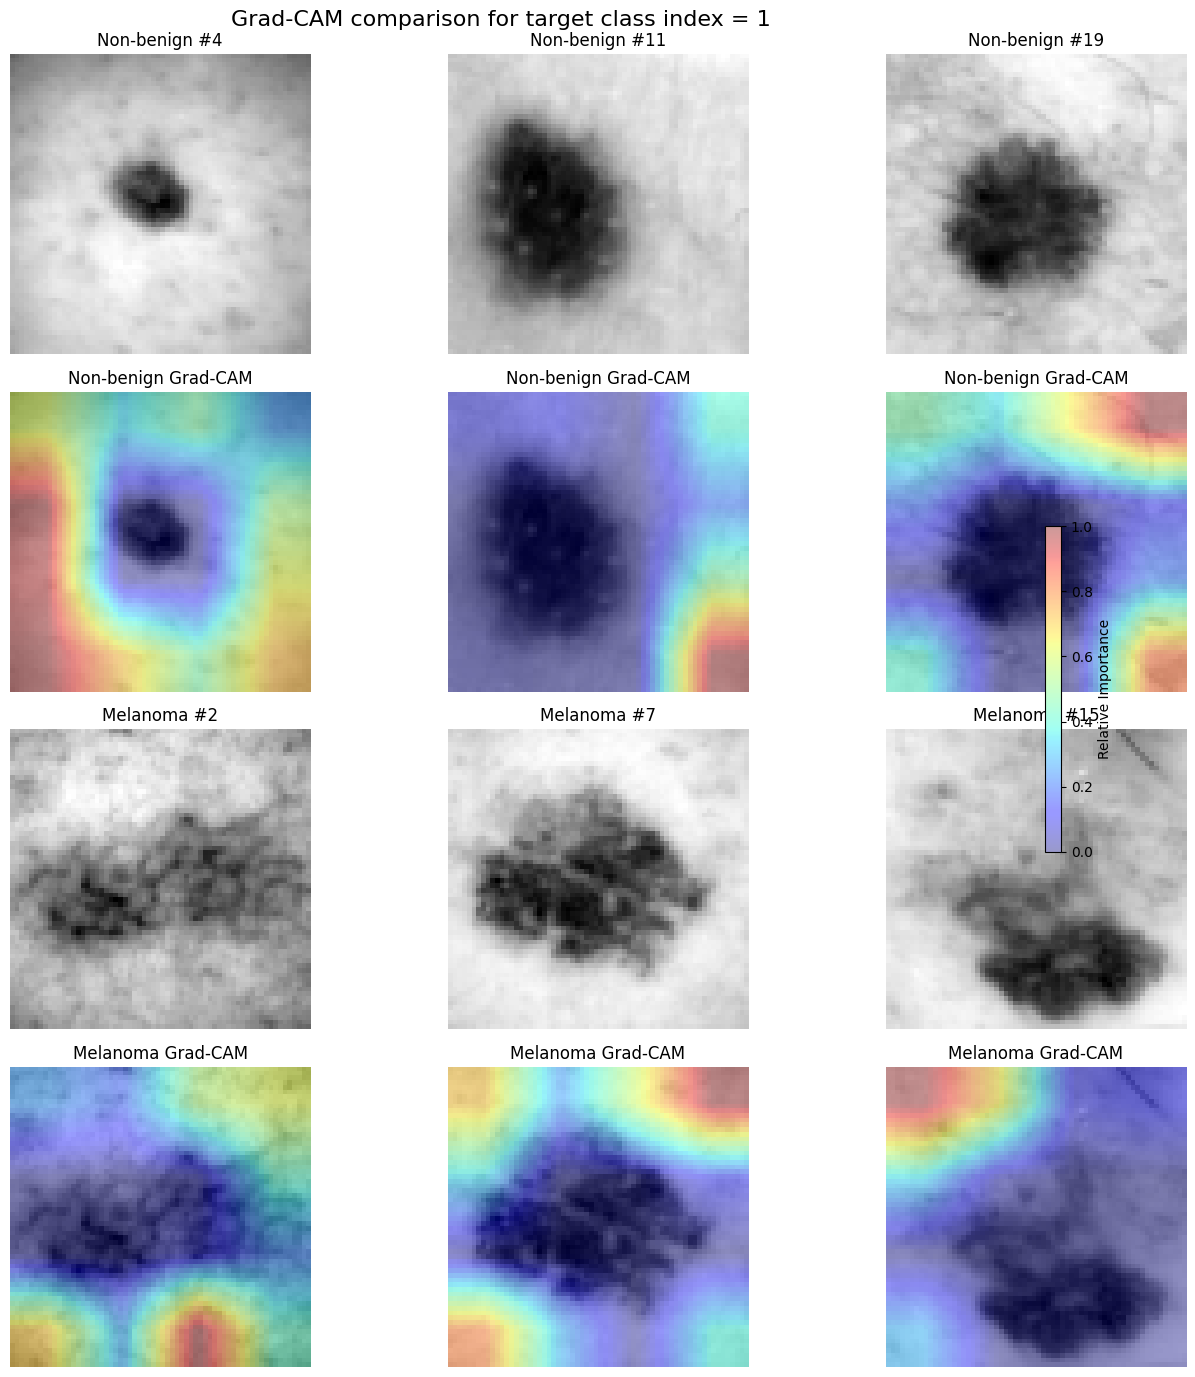

In [13]:
target_layer = model.layer3[-1]
melanoma_class_idx = 1

non_benign_indices = [4, 11, 19]
melanoma_indices = [2, 7, 15]

plot_gradcam_group_comparison(
    model=model,
    images=images,
    group1_indices=non_benign_indices,
    group2_indices=melanoma_indices,
    target_layer=target_layer,
    target_class_idx=melanoma_class_idx,
    group1_name="Non-benign",
    group2_name="Melanoma",
)